In [2]:

!pip install tensorflow==2.12.0
!pip install keras

Number of accelerators: 1
Found 3781 files belonging to 3 classes.
Using 3403 files for training.
Found 3781 files belonging to 3 classes.
Using 378 files for validation.
Classes: ['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


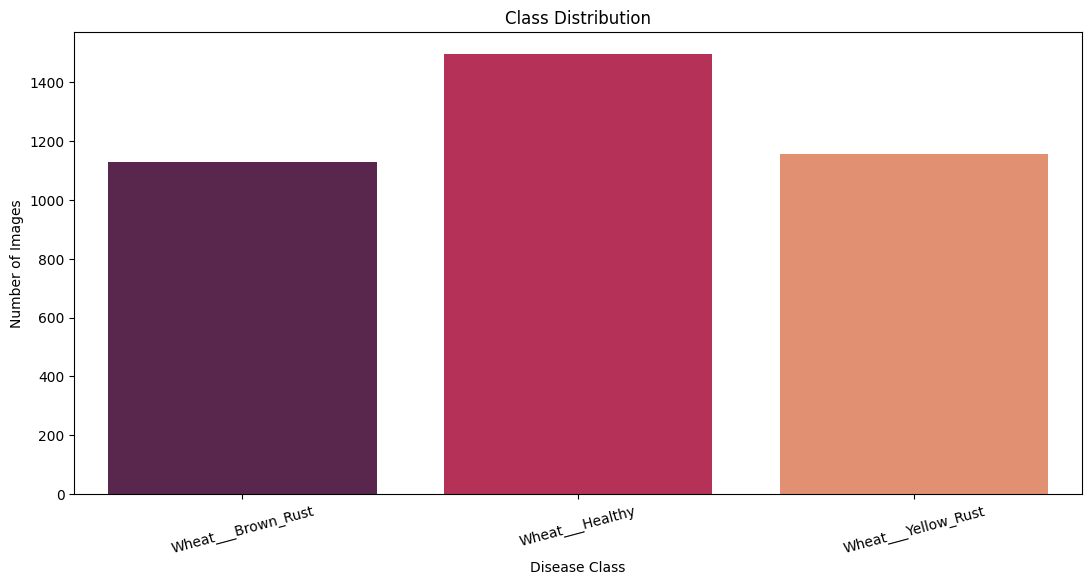


Class Weights:
Wheat___Brown_Rust: 1.12
Wheat___Healthy: 0.84
Wheat___Yellow_Rust: 1.09


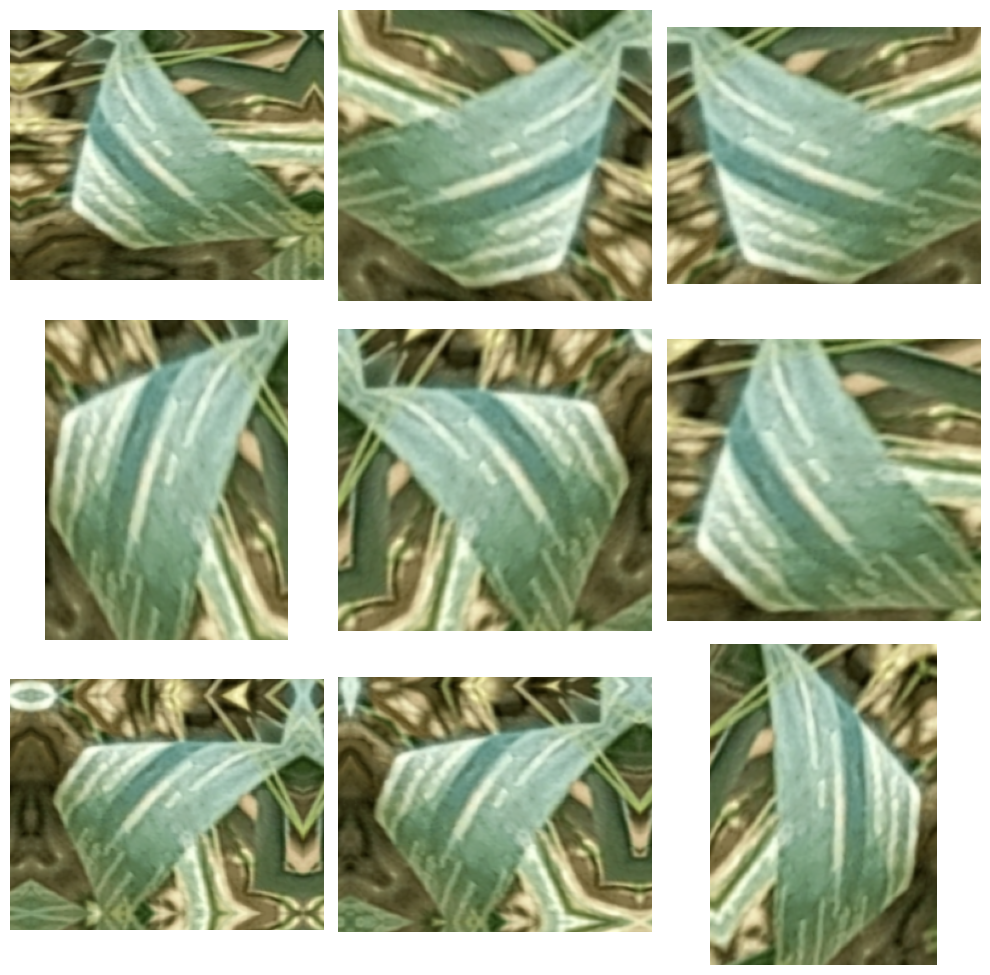

In [3]:
# Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

# Enable mixed precision only if using GPU with Tensor Cores
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()

print("Number of accelerators:", strategy.num_replicas_in_sync)

# Optional mixed precision
mixed_precision.set_global_policy('mixed_float16')

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42

# Dataset directory
directory = "/kaggle/input/wheat-leaf-diseases-dataset-from-bangladesh/Wheat Leaf Diseases Dataset From Bangladesh"

# Load training and validation sets
train_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='training',
    seed=SEED
)

validation_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='validation',
    seed=SEED
)

# Class names
class_names = train_dataset.class_names
print("Classes:", class_names)

# Class distribution for weight calculation
data_imbalance = []
for class_folder in class_names:
    file_list = gb.glob(os.path.join(directory, class_folder, '*.*'))
    data_imbalance.append(len(file_list))

# Visualize distribution
plt.figure(figsize=(13, 6))
sns.barplot(x=class_names, y=data_imbalance, palette="rocket")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Disease Class")
plt.xticks(rotation=15)
plt.show()

# Compute class weights
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}
print("\nClass Weights:")
for i, w in class_weight.items():
    print(f"{class_names[i]}: {w:.2f}")

# Data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        img = tf.cast(augmented_image[0], tf.float32) / 255.0
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Apply augmentation
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)




In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_mobilenetv3(input_shape=(224, 224, 3), num_classes=3, version="large", fine_tune=False):
    if version == "large":
        base_model = tf.keras.applications.MobileNetV3Large(
            input_shape=input_shape,
            include_top=False,
            weights="imagenet"
        )
    else:
        base_model = tf.keras.applications.MobileNetV3Small(
            input_shape=input_shape,
            include_top=False,
            weights="imagenet"
        )

    # Freeze the base model
    base_model.trainable = fine_tune  # Set to True to fine-tune

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


In [5]:
model = build_mobilenetv3(input_shape=(224, 224, 3), num_classes=len(class_names), version="large")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


12683000/12683000 [==============================] - 1s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3large (Functiona  (None, 7, 7, 960)        2996352   
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 960)              0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 960)              3840      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 960)               0      

In [6]:
# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1)
]

# Train
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    class_weight=class_weight,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
213/213 [==============================] - 282s 1s/step - loss: 1.2827 - accuracy: 0.4910 - val_loss: 0.6336 - val_accuracy: 0.7381 - lr: 1.0000e-04
Epoch 2/10
213/213 [==============================] - 249s 1s/step - loss: 0.6806 - accuracy: 0.7338 - val_loss: 0.3291 - val_accuracy: 0.8995 - lr: 1.0000e-04
Epoch 3/10
213/213 [==============================] - 230s 1s/step - loss: 0.4760 - accuracy: 0.8140 - val_loss: 0.2106 - val_accuracy: 0.9418 - lr: 1.0000e-04
Epoch 4/10
213/213 [==============================] - 248s 1s/step - loss: 0.3660 - accuracy: 0.8625 - val_loss: 0.1534 - val_accuracy: 0.9630 - lr: 1.0000e-04
Epoch 5/10
213/213 [==============================] - 231s 1s/step - loss: 0.3066 - accuracy: 0.8872 - val_loss: 0.1251 - val_accuracy: 0.9735 - lr: 1.0000e-04
Epoch 6/10
213/213 [==============================] - 247s 1s/step - loss: 0.2701 - accuracy: 0.9001 - val_loss: 0.1044 - val_accuracy: 0.9762 - lr: 1.0000e-04
Epoch 7/10
213/213 [====================

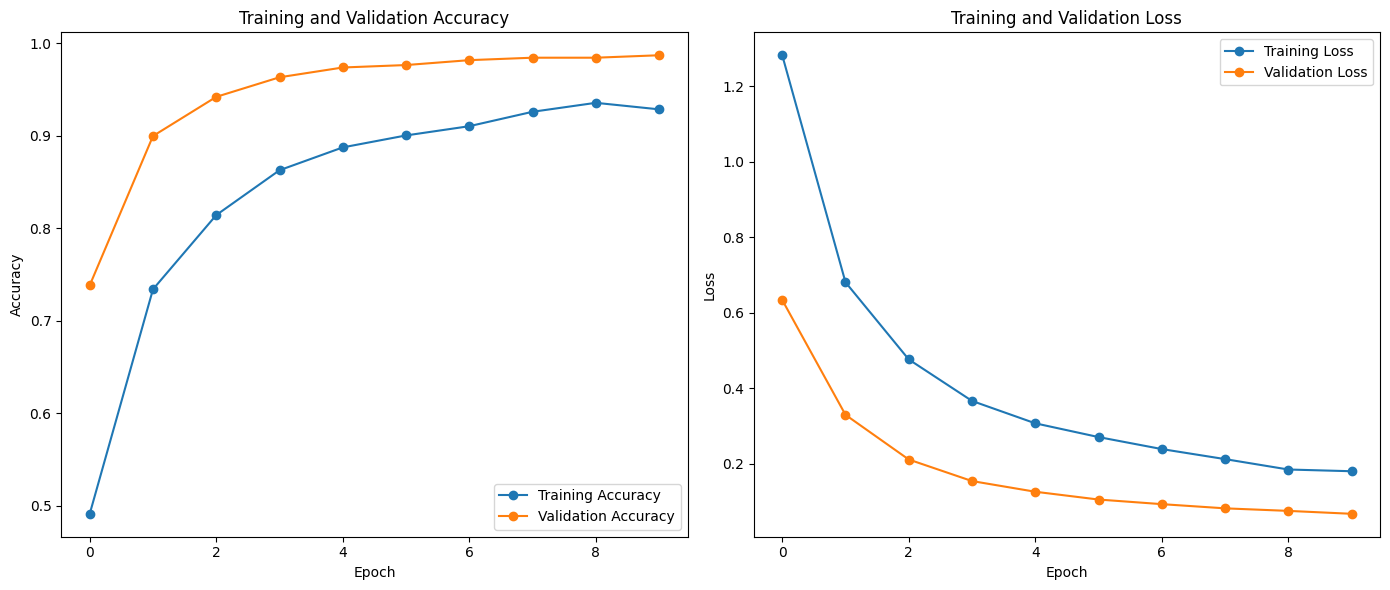

1/1 [==============================] - 1s 640ms/step
Class names: ['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']

Classification Report:

                     precision    recall  f1-score   support

 Wheat___Brown_Rust       0.99      0.96      0.97        94
    Wheat___Healthy       0.99      0.99      0.99       159
Wheat___Yellow_Rust       0.98      1.00      0.99       125

           accuracy                           0.99       378
          macro avg       0.99      0.98      0.98       378
       weighted avg       0.99      0.99      0.99       378



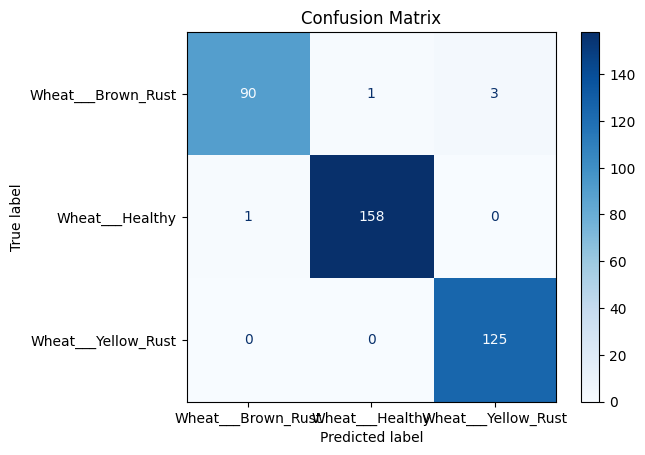

In [7]:
# Plot accuracy and loss
plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


true_labels = []
predicted_labels = []

for images, labels in validation_dataset:
    predictions = model(images, training=False)  # Slightly faster than .predict()
    predicted_classes = tf.argmax(predictions, axis=1).numpy()
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)



# Get true labels and predictions from validation dataset
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Class names
print("Class names:", class_names)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

